# Case Study II: 2024 KATL Taxiway Collision:

 - The incident occurred on Sept. 10 at approximately 10:07 a.m. as two aircraft, Delta Air Lines flight 295, an Airbus A350-941 (N503DN), and Endeavor Air flight 5526 (operating as Delta), a Mitsubishi CRJ-900 (N302PQ), collided while taxiing for departure.
 - https://www.fox5atlanta.com/news/ntsb-preliminary-report-two-delta-planes-collided-atlanta-airports-taxiway

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import spacy

nlp_ner = spacy.load("./transformer/model-best")
ruler = nlp_ner.add_pipe(
    "entity_ruler",
    after="ner",  # or before="ner"
    config={"overwrite_ents": True}  
)
ruler.from_disk("entity_rulers.jsonl")

text = "295 heavy turn on foxtrot hold short of ramp 5."
doc = nlp_ner(text)

print("Entities found:")
for ent in doc.ents:
    print(f" - {ent.text} : {ent.label_}")

Entities found:
 - 295 : CALLSIGN
 - turn : ACSTATE
 - foxtrot : DESTINATION
 - hold : ACSTATE
 - ramp 5 : DESTINATION


In [2]:
import re
import glob
import pandas as pd
import spacy
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util

###############################################################################
# 1. Runway Pattern Functions
###############################################################################
# This regex finds an optional "runway" followed by 1–2 digits and an optional L/R.
# It requires a whitespace, end-of-string, or common punctuation after the designator.

# def extract_all_runway_designators(text: str) -> list:
#     """
#     Return all runway designators found in the text as a list.
#     The designator must be one or two digits followed immediately by either L or R.
    
#     For example:
#       "17:43:12 ... runway 34R, continue approach" 
#     will return: ["34R"]
    
#     All designators are returned in uppercase.
#     """
#     matches = RUNWAY_REGEX.findall(text)
#     return [m.upper() for m in matches if m.strip()]

RUNWAY_REGEX = re.compile(
    r'(?i)(?:runway\s+)?(?P<number>\d{1,2})\s*(?:(?P<side>[LR])|(?P<sideWord>right|left))(?=\s|$|[.,;:!])'
)

def extract_all_runway_designators(text: str) -> list:
    """
    Return all runway designators found in the text as a list.
    This version recognizes designators written either as "34R" or as "8 right" (which is normalized to "08R").
    """
    designators = []
    for match in RUNWAY_REGEX.finditer(text):
        number = match.group("number")
        side = match.group("side")
        side_word = match.group("sideWord")
        # Format the number to always be two digits (e.g., "8" -> "08")
        number = number.zfill(2)
        if side_word:
            side = side_word[0].upper()  # Convert "right" or "left" to "R" or "L"
        if side:
            designators.append(f"{number}{side}")
        else:
            designators.append(number)
    return designators

def is_runway_pattern(text: str) -> bool:
    """Return True if at least one runway designator is found in the text."""
    return len(extract_all_runway_designators(text)) > 0

def format_runway_code(designator: str) -> str:
    """
    Format the runway designator by prepending 'RW'.
    For example, "8R" becomes "RW8R".
    """
    return f"RW{designator}"

def find_runway_entry_node(df: pd.DataFrame, runway_designator: str) -> str | None:
    """
    Given a runway designator (e.g. "8R"), look up the CSV row where that runway
    appears as an entry. In the CSV we assume that the runway entry is indicated by:
      - Either: refName1 equals the formatted runway code and type1 equals "Entry"
      - Or: refName2 equals the formatted runway code and type2 equals "Entry"
    Returns the node 'id' of the first matching row, or None if not found.
    """
    runway_code = format_runway_code(runway_designator)  # e.g. "RW8R"
    mask_ref1 = (df['refName1'] == runway_code) & (df['type1'].str.lower() == 'entry')
    mask_ref2 = (df['refName2'] == runway_code) & (df['type2'].str.lower() == 'entry')
    match_mask = mask_ref1 | mask_ref2
    matched_rows = df[match_mask]
    if not matched_rows.empty:
        return matched_rows.iloc[0]['id']
    return None

###############################################################################
# 2. Node Similarity Functions for Non-Runway Destinations
###############################################################################
def build_id_embeddings(df: pd.DataFrame, model_name='sentence-transformers/all-MiniLM-L6-v2'):
    """
    Build embeddings for the 'id' column of the CSV.
    Returns a tuple (model, embeddings).
    """
    model = SentenceTransformer(model_name)
    texts = df['id'].astype(str).tolist()
    embeddings = model.encode(texts, convert_to_tensor=True)
    return model, embeddings

def find_topk_similar_nodes(query: str, df: pd.DataFrame, model, embeddings, top_k=5):
    """
    Compute top-k similarity between the query and the embedded node IDs.
    Returns a list of dictionaries with the node id and similarity score.
    """
    query_emb = model.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_emb, embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    results = []
    all_ids = df['id'].tolist()
    for i, idx_tensor in enumerate(top_results.indices):
        idx = idx_tensor.item()
        score = top_results.values[i].item()
        results.append({
            "id": all_ids[idx],
            "similarity_score": float(score)
        })
    return results

###############################################################################
# 3. Main Function: Build the Meta Table from the Transcript
###############################################################################
if __name__ == "__main__":
    # --- Load your pretrained spaCy model and add your entity ruler ---
    nlp_ner = spacy.load("./transformer/model-best")
    # Add the entity ruler (adjust the pipe position as needed)
    ruler = nlp_ner.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": True})
    ruler.from_disk("entity_rulers.jsonl")
    
    # --- Load the CSV with airport nodes ---
    ICAO = 'KATL'
    airport_nodes = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
    df = pd.read_csv(airport_nodes)
    
    # Build embeddings for non-runway similarity search on the node "id" column.
    model_id, id_embeddings = build_id_embeddings(df)
    
    # List to collect meta table rows.
    meta_rows = []
    
    # --- Process transcript files ---
    test_file_paths = glob.glob('/home/yp6443/research/nlp/voice_data/test_file/*.txt')
    file_idx = 0  # adjust as needed

    with open(test_file_paths[file_idx], 'r') as file:
        for line in file:
            line_text = line.strip()
            if not line_text:
                continue
            
            # Extract the time as the first token in the line.
            time_val = line_text.split()[0]
            
            # Run your spaCy NER on the line.
            doc = nlp_ner(line_text)
            print(f"\nLine: \"{line_text}\"")
            print("Entities found:")
            for ent in doc.ents:
                print(f"  - {ent.text} : {ent.label_}")
            
            # Initialize fields (if an entity is missing, the field remains empty).
            callsign = ""
            destination_text = ""
            ac_state_list = []
            
            # Extract entity values (adjust label names as used by your model).
            for ent in doc.ents:
                if ent.label_ == "CALLSIGN":
                    callsign = ent.text
                elif ent.label_ == "DESTINATION":
                    destination_text = ent.text
                elif ent.label_ == "ACSTATE":  # or "AC_STATE" if that is your model's label
                    ac_state_list.append(ent.text)
            ac_state = ",".join(ac_state_list)
            
            # --- Determine the destination runway and final destination ---
            # First, try applying the regex to the entire line.
            designators_line = extract_all_runway_designators(line_text)
            if designators_line:
                # If found in the entire line, choose the last designator.
                chosen = designators_line[-1]
                dest_runway = chosen
                entry_node = find_runway_entry_node(df, chosen)
                if entry_node:
                    final_destination = entry_node
                else:
                    final_destination = f"No entry found for runway {chosen}"
            else:
                # Otherwise, fall back to checking the DESTINATION entity.
                if destination_text and is_runway_pattern(destination_text):
                    designators = extract_all_runway_designators(destination_text)
                    chosen = designators[-1] if designators else None
                    if chosen:
                        dest_runway = chosen
                        entry_node = find_runway_entry_node(df, chosen)
                        if entry_node:
                            final_destination = entry_node
                        else:
                            final_destination = f"No entry found for runway {chosen}"
                    else:
                        final_destination = destination_text
                        dest_runway = ""
                else:
                    dest_runway = ""
                    # For non-runway orders, use the destination_text.
                    final_destination = destination_text
            
            # Build a meta table row.
            meta_row = {
                "callsign": callsign,
                "time": time_val,
                "ac_state": ac_state,
                "dest_runway": dest_runway,
                "destination": final_destination
            }
            meta_rows.append(meta_row)
    
    # Create and print the meta table.
    meta_df = pd.DataFrame(meta_rows, columns=["callsign", "time", "ac_state", "dest_runway", "destination"])
    
    # -----------------------
    # Post-Processing Step:
    # For each callsign, if a dest_runway is provided on any row, propagate it to all rows of that callsign.
    # Replace empty strings with NaN for proper filling.
    meta_df['dest_runway'] = meta_df['dest_runway'].replace('', np.nan)
    # For each callsign, forward-fill then backward-fill the dest_runway.
    meta_df['dest_runway'] = meta_df.groupby('callsign')['dest_runway'].transform(lambda x: x.ffill().bfill())
    # Replace NaN back with an empty string if desired.
    meta_df['dest_runway'] = meta_df['dest_runway'].fillna('')
    # -----------------------
    meta_df = meta_df[~meta_df['time'].isin(['N/A'])]
    
    print("\nFinal Meta Table:")
    print(meta_df.reset_index(drop=True))



Line: "0:08 And Delta 295 heavy taxi with Romeo."
Entities found:
  - Delta 295 : CALLSIGN
  - taxi : ACSTATE
  - Romeo : DESTINATION

Line: "0:14 Delta 295 heavy Atlanta ground runway 8R taxi golf short of foxtrot."
Entities found:
  - Delta 295 : CALLSIGN
  - runway : DESTINATION
  - taxi : ACSTATE
  - foxtrot : DESTINATION

Line: "0:20 Taxi via golf short of foxtrot Delta 295."
Entities found:
  - Taxi : ACSTATE
  - foxtrot : DESTINATION
  - Delta 295 : CALLSIGN

Line: "0:33 Delta 295 heavy continue via a left turn on foxtrot hold short of ramp 5."
Entities found:
  - Delta 295 : CALLSIGN
  - continue : ACSTATE
  - foxtrot : DESTINATION
  - hold : ACSTATE
  - ramp 5 : DESTINATION

Line: "0:36 Alright, make a left on Foxtrot short of ramp 5 Delta 295 thank you."
Entities found:
  - Foxtrot : DESTINATION
  - ramp 5 : DESTINATION
  - Delta 295 : CALLSIGN

Line: "0:44 Delta 295 heavy ramp 5 give way to that opposite direction 717 inbound and then join Echo."
Entities found:
  - Delta 2

In [3]:
print("Meta Table:")
pd.set_option('display.max_rows', None)
meta_df

Meta Table:


,callsign,time,ac_state,dest_runway,destination
0,Delta 295,0:08,taxi,08R,Romeo
1,Delta 295,0:14,taxi,08R,Rwy_02_001
2,Delta 295,0:20,Taxi,08R,foxtrot
3,Delta 295,0:33,"continue,hold",08R,ramp 5
4,Delta 295,0:36,,08R,ramp 5
5,Delta 295,0:44,"give way,inbound,join",08R,Echo
6,Delta 295,0:50,give way,08R,
7,Endeavor 5526,0:57,taxi,08R,Rwy_02_001
8,Endeavor 5526,1:01,,08R,
9,Delta 295,1:03,,08R,


In [4]:
meta_df = meta_df[meta_df['ac_state'].str.strip() != '']

accident_time = "2:10"
accident_callsign = "Endeavor 5526"
new_row_1 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }

meta_df = pd.concat([meta_df, pd.DataFrame([new_row_1])], ignore_index=True)
    
accident_callsign = "Delta 295"
new_row_2 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }
meta_df = pd.concat([meta_df, pd.DataFrame([new_row_2])], ignore_index=True)

meta_df

,callsign,time,ac_state,dest_runway,destination
0,Delta 295,0:08,taxi,08R,Romeo
1,Delta 295,0:14,taxi,08R,Rwy_02_001
2,Delta 295,0:20,Taxi,08R,foxtrot
3,Delta 295,0:33,"continue,hold",08R,ramp 5
4,Delta 295,0:44,"give way,inbound,join",08R,Echo
5,Delta 295,0:50,give way,08R,
6,Endeavor 5526,0:57,taxi,08R,Rwy_02_001
7,Delta 295,1:27,go,08R,
8,,1:29,"stop,stop",,
9,Delta 295,1:35,"continue,hold",08R,


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# === Load the airport nodes CSV ===
ICAO = 'KATL'
airport_nodes_path = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
df_nodes = pd.read_csv(airport_nodes_path)
# (Assume df_nodes has a column called "id" that contains node names.)

# === Build embeddings for the airport nodes based on the "id" column ===
# (Assuming your build_id_embeddings function returns a model with an .encode() method and the list/array of embeddings.)
model_id, id_embeddings = build_id_embeddings(df_nodes)
# For example, id_embeddings might be a NumPy array of shape (num_nodes, embedding_dim).

# === Define a function to return the top k most similar node ids given a query string ===
def get_top_k_similar(query, model, embeddings, node_ids, k=3):
    """
    Given a query string, a model, and precomputed embeddings for node_ids,
    returns the top k most similar node ids along with their similarity scores.
    """
    # Compute embedding for the query string:
    query_embedding = model.encode(query)
    
    # Compute cosine similarity between the query and all node embeddings:
    sims = cosine_similarity([query_embedding], embeddings)[0]
    
    # Get indices for the top k similar nodes (sorted by descending similarity):
    top_indices = np.argsort(sims)[::-1][:k]
    
    # Return a list of tuples: (node_id, similarity score)
    return [(node_ids[i], sims[i]) for i in top_indices]

# === Filter the flight log for rows where the destination matches any of the target keywords ===
# Define your target keywords
keywords = ['romeo', 'foxtrot', 'ramp5', 'echo', 'victor']

# Create a regex pattern that matches any of these keywords.
# The pipe character '|' acts as a logical OR in regex.
pattern = '|'.join(keywords)

# Assuming your flight log DataFrame is called meta_df, create the mask:
mask = meta_df['destination'].str.contains(pattern, case=False, na=False)

# Filter the DataFrame and remove duplicate destination entries (if needed)
df_filtered = meta_df[mask].drop_duplicates(subset=['destination'])

# Get the list of node ids from the airport nodes DataFrame.
node_ids = df_nodes['id'].tolist()

# === For each filtered destination, find the top k similar node names ===
k = 5  # Adjust as needed
for idx, row in df_filtered.iterrows():
    destination_query = row['destination']
    similar_nodes = get_top_k_similar(destination_query, model_id, id_embeddings, node_ids, k=k)
    print(f"Destination '{destination_query}' top {k} similar nodes:")
    for node_name, score in similar_nodes:
        print(f"  {node_name}: {score:.4f}")
    print()


Destination 'Romeo' top 5 similar nodes:
  Txy_LC_M: 0.3394
  Txy_M_LA: 0.3384
  Txy_LC_L: 0.3383
  Txy_L_LB: 0.3357
  Txy_M_LB: 0.3331

Destination 'foxtrot' top 5 similar nodes:
  Rwy_05_004: 0.2601
  Txy_M_T: 0.2583
  Txy_R_R10: 0.2582
  Rwy_05_005: 0.2570
  Rwy_05_002: 0.2565

Destination 'Echo' top 5 similar nodes:
  Txy_V_H: 0.3596
  Txy_D_L: 0.3435
  Txy_L_LA: 0.3360
  Txy_LC_L: 0.3342
  Txy_D_E: 0.3313

Destination 'Victor' top 5 similar nodes:
  Rwy_03_015: 0.2422
  Rwy_02_005: 0.2411
  Gate_E_007: 0.2393
  Gate_B_029: 0.2389
  Gate_B_026: 0.2384



In [6]:
from KShortestPaths_TaxiPlanGenerator import *

airports = [
    "AMS", "BOM", "CAI", "CDG", "DEL", "DME", "DXB", "FCO", "FRA", "HKG", "HND",
    "ICN", "IST", "JNB", "KABQ", "KATL", "KBDL", "KBHM", "KBNA", "KBOI", "KBOS",
    "KBTV", "KBUR", "KBWI", "KBZN", "KCHS", "KCLE", "KCLT", "KCRW", "KCVG", "KDAL",
    "KDCA", "KDEN", "KDFW", "KDSM", "KDTW", "KEWR", "KFAR", "KFLL", "KFSD", "KGYY",
    "KHPN", "KIAD", "KIAH", "KICT", "KILG", "KIND", "KISP", "KJAC", "KJAN", "KJAX",
    "KJFK", "KLAS", "KLAX", "KLEX", "KLGA", "KLGB", "KLIT", "KMCO", "KMDW", "KMEM",
    "KMHT", "KMIA", "KMKE", "KMSP", "KMSY", "KOAK", "KOKC", "KOMA", "KONT", "KORD",
    "KPBI", "KPDX", "KPHL", "KPHX", "KPIT", "KPVD", "KPWM", "KSAN", "KSAT", "KSDF",
    "KSEA", "KSFO", "KSJC", "KSLC", "KSNA", "KSTL", "KSWF", "KTEB", "KTPA", "KUL",
    "KVGT", "LHR", "MAD", "MEX", "PANC", "PEK", "PHNL", "PVG", "SIN", "SYD", "TLV",
    "TPE", "YYZ"
]
defFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Def.csv" for airport in airports]
linkFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Links.csv" for airport in airports]
graphs, nodePositions = loadData(defFiles, linkFiles)

graph = graphs.get(ICAO)
positions = nodePositions.get(ICAO)

# Endeavor 5526
start1 = 'Txy_3N_002'
end1 = 'Rwy_02_001'
end1 = 'Txy_E_002'
# Delta 295
start2 = 'Txy_E_005'
end2 = 'Txy_V_003'
end2 = 'Txy_E_002'
# generate path from A-star
NUM_PATHS = 1
path1 = aStarMultiple(graph, start1, end1, positions, k=NUM_PATHS)
path2 = aStarMultiple(graph, start2, end2, positions, k=NUM_PATHS)

print('Endeavor 5526 Possible Paths:')
for i, (path, distance) in enumerate(path1, start=1):
    print(f"Path {i}: {path}, Distance: {distance:.2f} mile")

print('Delta 295 Possible Paths:')
for i, (path, distance) in enumerate(path2, start=1):
    print(f"Path {i}: {path}, Distance: {distance:.2f} mile")

Endeavor 5526 Possible Paths:
Path 1: ['Txy_3N_002', 'Txy_F_005', 'Txy_F_104', 'Txy_E_004', 'Txy_E_003', 'Txy_E_002'], Distance: 0.34 mile
Delta 295 Possible Paths:
Path 1: ['Txy_E_005', 'Txy_E_104', 'Txy_E_004', 'Txy_E_003', 'Txy_E_002'], Distance: 0.42 mile


In [15]:
# ----------------------------
# Segment-Specific Timing Simulation
# ----------------------------

import math
import io
import os
import imageio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def calculate_segment_distances(path, nodePositions):
    """Calculate distances for each segment in the path"""
    distances = []
    for i in range(len(path) - 1):
        pos1 = nodePositions[path[i]]
        pos2 = nodePositions[path[i+1]]
        # Calculate distance in miles (assuming lat/lon are in degrees)
        # Rough conversion: 1 degree ≈ 69 miles
        distance_miles = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 69
        distances.append(distance_miles)
    return distances

def calculate_proportional_segment_times(path, nodePositions, total_time_seconds=120):
    """
    Calculate segment times proportional to segment distances, totaling total_time_seconds.
    """
    distances = calculate_segment_distances(path, nodePositions)
    total_distance = sum(distances)
    
    if total_distance == 0:
        # If no distance, distribute time equally
        return [total_time_seconds // len(distances)] * len(distances)
    
    segment_times = []
    for distance in distances:
        time_sec = (distance / total_distance) * total_time_seconds
        segment_times.append(int(time_sec))
    
    # Adjust last segment to ensure total is exactly total_time_seconds
    current_total = sum(segment_times)
    if current_total != total_time_seconds:
        segment_times[-1] += (total_time_seconds - current_total)
    
    return segment_times

def get_position_along_path_precise_timing(path, nodePositions, segment_times, t):
    """
    Given a list of node IDs in 'path', returns the interpolated position (lat, lon)
    at simulation time t (in seconds), based on precise timing for each segment.
    """
    # Ensure we have the right number of segment times
    if len(segment_times) != len(path) - 1:
        raise ValueError(f"segment_times must have {len(path) - 1} elements, got {len(segment_times)}")

    # Compute cumulative times along the path segments
    cum_times = [0]
    for i in range(len(segment_times)):
        cum_times.append(cum_times[-1] + segment_times[i])
    
    total_time = cum_times[-1]

    # If we've passed the total time, return the final node position.
    if t >= total_time:
        return nodePositions[path[-1]], total_time

    # Find the segment where the current time lies.
    for i in range(1, len(cum_times)):
        if t < cum_times[i]:
            pos1 = nodePositions[path[i-1]]
            pos2 = nodePositions[path[i]]
            seg_progress = (t - cum_times[i-1]) / (cum_times[i] - cum_times[i-1])
            lat = pos1[0] + seg_progress * (pos2[0] - pos1[0])
            lon = pos1[1] + seg_progress * (pos2[1] - pos1[1])
            return (lat, lon), total_time

def draw_background(ax, linksDf, nodePositions, airport_name, xlims=None, ylims=None):
    """Draws the airport layout (links and nodes) on the given axis."""
    # Helper function to check if a point is within the limits.
    def is_within(lon, lat):
        within_x = True if xlims is None else (xlims[0] <= lon <= xlims[1])
        within_y = True if ylims is None else (ylims[0] <= lat <= ylims[1])
        return within_x and within_y

    # Draw taxiway/runway links.
    for _, row in linksDf.iterrows():
        try:
            n1_lon = float(row['n1.lon'])
            n1_lat = float(row['n1.lat'])
            n2_lon = float(row['n2.lon'])
            n2_lat = float(row['n2.lat'])
        except Exception as e:
            continue

        if (xlims is not None or ylims is not None) and not (is_within(n1_lon, n1_lat) or is_within(n2_lon, n2_lat)):
            continue
                
        ax.plot([n1_lon, n2_lon], [n1_lat, n2_lat],
                color='gray', linestyle='-', linewidth=0.5, clip_on=True)

    # Draw nodes and labels only if they are within the specified area.
    for nodeId, (lat, lon) in nodePositions.items():
        try:
            lat = float(lat)
            lon = float(lon)
        except Exception as e:
            continue

        if (xlims is not None or ylims is not None) and not is_within(lon, lat):
            continue
        ax.scatter(lon, lat, color='blue', s=20, zorder=2, clip_on=True)
        ax.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom', clip_on=True)
        
    # Set the axis limits to enforce the zoom.
    if xlims is not None:
        ax.set_xlim(xlims)
    if ylims is not None:
        ax.set_ylim(ylims)
        
    ax.set_xlabel('Longitude [$^\circ$]')
    ax.set_ylabel('Latitude [$^\circ$]')
    ax.set_title(f'{airport_name} Layout')
    ax.grid(False)

def animate_with_collision_detection(linksDf, nodePositions, path1, segment_times1, path2, segment_times2, 
                                   airport_name, output_filename, xlims=None, ylims=None, 
                                   time_lag=0, collision_threshold=0.001, save_frames_dir=None):
    """
    Animates two aircraft with precise timing control and collision detection.
    Stops simulation when aircraft get within collision_threshold distance of each other.
    """
    
    # Calculate total times
    total_time1 = sum(segment_times1)
    total_time2 = sum(segment_times2)
    overall_total_time = max(total_time1, total_time2 + time_lag)
    
    print(f"Aircraft 1 total time: {total_time1} seconds")
    print(f"Aircraft 2 total time: {total_time2} seconds")
    print(f"Aircraft 2 starts at: {time_lag} seconds")
    print(f"Collision threshold: {collision_threshold} degrees")
    
    # Time series data collection
    time_series_data = {
        't': [],
        'aircraft1_lat': [],
        'aircraft1_lon': [],
        'aircraft1_speed': [],
        'aircraft1_next_node': [],
        'aircraft2_lat': [],
        'aircraft2_lon': [],
        'aircraft2_speed': [],
        'aircraft2_next_node': [],
        'distance': [],
        'collision_detected': []
    }
    
    # Calculate segment speeds for time series
    distances1 = calculate_segment_distances(path1, nodePositions)
    distances2 = calculate_segment_distances(path2, nodePositions)
    segment_speeds1 = [d/t if t > 0 else 0 for d, t in zip(distances1, segment_times1)]
    segment_speeds2 = [d/t if t > 0 else 0 for d, t in zip(distances2, segment_times2)]
    
    frames = []
    collision_time = None
    
    for t in range(overall_total_time + 1):
        # Calculate positions for both aircraft
        pos1, _ = get_position_along_path_precise_timing(path1, nodePositions, segment_times1, t)
        
        # Aircraft 2 starts after time_lag
        if t >= time_lag:
            pos2, _ = get_position_along_path_precise_timing(path2, nodePositions, segment_times2, t - time_lag)
        else:
            pos2 = nodePositions[path2[0]]  # Start position
        
        # Calculate distance between aircraft
        distance = math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)
        
        # Determine current segment and speed for each aircraft
        speed1 = 0
        next_node1 = None
        if t < total_time1:
            cum_time = 0
            for i, seg_time in enumerate(segment_times1):
                if t < cum_time + seg_time:
                    speed1 = segment_speeds1[i] if i < len(segment_speeds1) else 0
                    next_node1 = path1[i+1] if i+1 < len(path1) else None
                    break
                cum_time += seg_time
        
        speed2 = 0
        next_node2 = None
        if t >= time_lag and (t - time_lag) < total_time2:
            cum_time = 0
            for i, seg_time in enumerate(segment_times2):
                if (t - time_lag) < cum_time + seg_time:
                    speed2 = segment_speeds2[i] if i < len(segment_speeds2) else 0
                    next_node2 = path2[i+1] if i+1 < len(path2) else None
                    break
                cum_time += seg_time
        
        # Check for collision
        collision_detected = distance < collision_threshold
        if collision_detected and collision_time is None:
            collision_time = t
            print(f"COLLISION DETECTED at t={t} seconds!")
            print(f"Distance between aircraft: {distance:.6f} degrees")
            print(f"Aircraft 1 position: ({pos1[0]:.6f}, {pos1[1]:.6f})")
            print(f"Aircraft 2 position: ({pos2[0]:.6f}, {pos2[1]:.6f})")
        
        # Record time series data
        time_series_data['t'].append(t)
        time_series_data['aircraft1_lat'].append(pos1[0])
        time_series_data['aircraft1_lon'].append(pos1[1])
        time_series_data['aircraft1_speed'].append(speed1)
        time_series_data['aircraft1_next_node'].append(next_node1)
        time_series_data['aircraft2_lat'].append(pos2[0])
        time_series_data['aircraft2_lon'].append(pos2[1])
        time_series_data['aircraft2_speed'].append(speed2)
        time_series_data['aircraft2_next_node'].append(next_node2)
        time_series_data['distance'].append(distance)
        time_series_data['collision_detected'].append(collision_detected)
        
        # Stop simulation if collision detected
        if collision_detected:
            break
        
        # Create a new figure for this frame.
        fig, ax = plt.subplots(figsize=(10, 10))
        # Set custom zoom (if provided) to focus on the area of interest.
        if xlims is not None:
            ax.set_xlim(xlims)
        if ylims is not None:
            ax.set_ylim(ylims)
            
        draw_background(ax, linksDf, nodePositions, airport_name, xlims=None, ylims=None)
        
        # Plot the planned paths.
        path1_lats = [nodePositions[node][0] for node in path1]
        path1_lons = [nodePositions[node][1] for node in path1]
        ax.plot(path1_lons, path1_lats, color='red', linestyle='--', linewidth=2, label='Endeavor 5526')
        
        path2_lats = [nodePositions[node][0] for node in path2]
        path2_lons = [nodePositions[node][1] for node in path2]
        ax.plot(path2_lons, path2_lats, color='green', linestyle='--', linewidth=2, label='Delta 295')
        
        # Plot the current positions.
        ax.scatter(pos1[1], pos1[0], color='red', s=50, zorder=3, label='Endeavor 5526' if t==0 else "")
        ax.scatter(pos2[1], pos2[0], color='green', s=50, zorder=3, label='Delta 295' if t==0 else "")
        
        # Display simulation time and distance.
        ax.text(0.05, 0.95, f"t = {t} s", transform=ax.transAxes,
                fontsize=12, color='black', verticalalignment='top')
        ax.text(0.05, 0.90, f"Distance = {distance:.6f}°", transform=ax.transAxes,
                fontsize=12, color='black', verticalalignment='top')
        
        if collision_detected:
            ax.text(0.05, 0.85, "COLLISION!", transform=ax.transAxes,
                    fontsize=14, color='red', verticalalignment='top', weight='bold')
        
        # Add legend (only once).
        ax.legend(loc='upper right')
        
        if save_frames_dir:
            # Save each frame as a PNG file.
            frame_filename = os.path.join(save_frames_dir, f'{airport_name}_frame_{t:04d}.png')
            plt.savefig(frame_filename, format='png', dpi=300)
        else:
            # Save the frame to an in-memory buffer.
            buf = io.BytesIO()
            plt.savefig(buf, format='png')
            buf.seek(0)
            image = imageio.imread(buf)
            frames.append(image)
        
        plt.close(fig)
    
    # Save time series data to CSV
    df_timeseries = pd.DataFrame(time_series_data)
    df_timeseries.to_csv(f'{airport_name}_collision_simulation.csv', index=False)
    print(f"Time series data saved to {airport_name}_collision_simulation.csv")
    
    if not save_frames_dir:
        # Save all frames as an animated GIF if not saving individual images.
        imageio.mimsave(output_filename, frames, duration=0.1)
        print(f"Animation saved to {output_filename}")
    
    return collision_time, df_timeseries


Endeavor 5526 segment times (seconds): [10, 6, 17, 56, 31]
Delta 295 segment times (seconds): [30, 23, 43, 24]

Endeavor 5526 total time: 120 seconds
Delta 295 total time: 120 seconds

Endeavor 5526 derived speeds (mph): ['0.0', '0.0', '0.0', '0.0', '0.0']
Delta 295 derived speeds (mph): ['0.0', '0.0', '0.0', '0.0']
Aircraft 1 total time: 120 seconds
Aircraft 2 total time: 120 seconds
Aircraft 2 starts at: 0 seconds
Collision threshold: 0.0005 degrees


/tmp/ipykernel_2782040/3569569562.py:275: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(buf)


KeyboardInterrupt: 

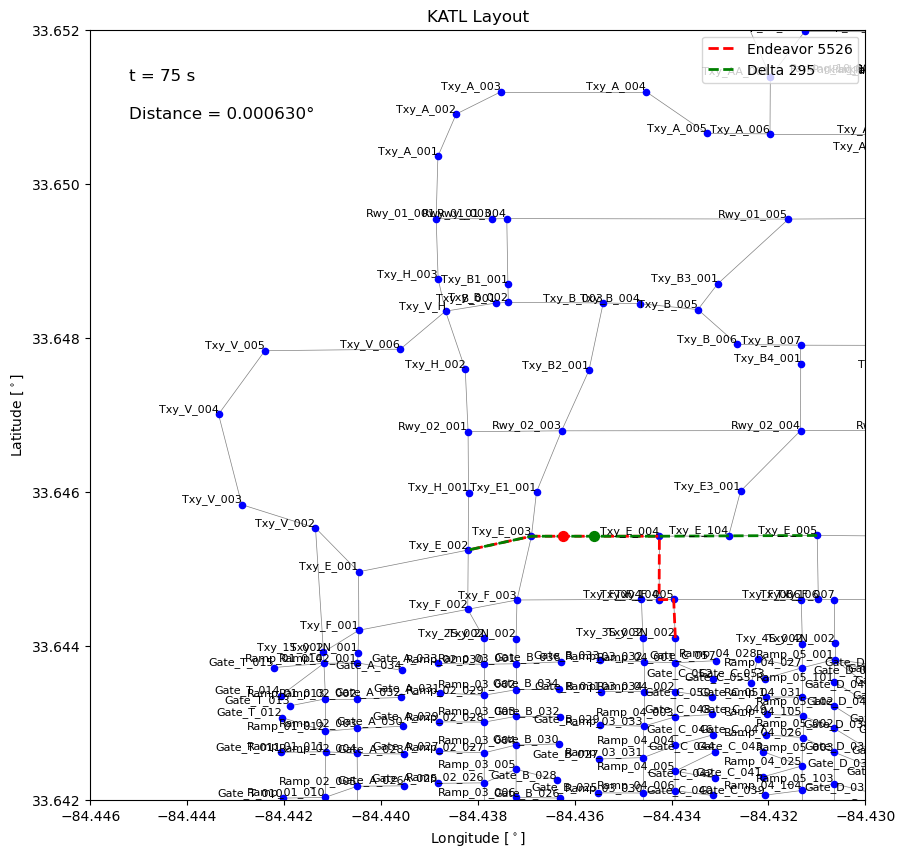

In [16]:
# ----------------------------
# Run Simulation
# ----------------------------

# Calculate segment times for both aircraft (120 seconds total each)
edv_segment_times = calculate_proportional_segment_times(path_edv, nodePositions, 120)
delta_segment_times = calculate_proportional_segment_times(path_delta, nodePositions, 120)

print("Endeavor 5526 segment times (seconds):", edv_segment_times)
print("Delta 295 segment times (seconds):", delta_segment_times)

# Calculate total travel times
edv_total_time = sum(edv_segment_times)
delta_total_time = sum(delta_segment_times)

print(f"\nEndeavor 5526 total time: {edv_total_time} seconds")
print(f"Delta 295 total time: {delta_total_time} seconds")

# Calculate derived speeds for reference
edv_distances = calculate_segment_distances(path_edv, nodePositions)
delta_distances = calculate_segment_distances(path_delta, nodePositions)

edv_speeds = [d/t if t > 0 else 0 for d, t in zip(edv_distances, edv_segment_times)]
delta_speeds = [d/t if t > 0 else 0 for d, t in zip(delta_distances, delta_segment_times)]

print(f"\nEndeavor 5526 derived speeds (mph): {[f'{s:.1f}' for s in edv_speeds]}")
print(f"Delta 295 derived speeds (mph): {[f'{s:.1f}' for s in delta_speeds]}")

# Run the collision detection simulation
collision_time, df_timeseries = animate_with_collision_detection(
    linksDf=linksDf,
    nodePositions=nodePositions,
    path1=path_edv,
    segment_times1=edv_segment_times,
    path2=path_delta,
    segment_times2=delta_segment_times,
    airport_name=ICAO,
    output_filename='case-study-2-collision-detection.gif',
    xlims=xlims,
    ylims=ylims,
    time_lag=0,  # Both aircraft start at the same time
    collision_threshold=0.0005,  # Collision threshold in degrees
    save_frames_dir=None
)

# Display results
print(f"\nSimulation Results:")
print(f"Collision detected at: {collision_time} seconds" if collision_time else "No collision detected")
print(f"Total simulation time: {len(df_timeseries)} seconds")

# Show first few rows of time series data
print(f"\nTime series data preview:")
print(df_timeseries.head(10))

# Show last few rows (around collision if it occurred)
if collision_time:
    print(f"\nData around collision time:")
    collision_idx = df_timeseries[df_timeseries['collision_detected'] == True].index
    if len(collision_idx) > 0:
        start_idx = max(0, collision_idx[0] - 2)
        end_idx = min(len(df_timeseries), collision_idx[0] + 3)
        print(df_timeseries.iloc[start_idx:end_idx])


In [ ]:
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance (in kilometers) between two points on Earth."""
    R = 6371  # Earth radius in kilometers
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi/2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda/2)**2
    distance = 2 * R * math.asin(math.sqrt(a))
    return distance

# Node coordinates from GCXO_Nodes_Def.csv
nodes = {
    'Rwy_12_001': (28.487889, -16.357273),
    'Rwy_12_002': (28.485553, -16.350255),
    'Rwy_12_003': (28.483932, -16.345360),
    'Rwy_12_004': (28.482443, -16.340874),
    'Rwy_12_005': (28.481667, -16.338548),
    'Rwy_12_006': (28.477426, -16.325730),
    'Txy_C0_001': (28.488761, -16.356464),
    'Txy_C0_002': (28.488325, -16.357476)
}

# Calculate distances for each link
links = [
    ('Txy_C0_001', 'Txy_C0_002'),
    ('Txy_C0_002', 'Rwy_12_001'),
    ('Rwy_12_001', 'Rwy_12_002'),
    ('Rwy_12_002', 'Rwy_12_003'),
    ('Rwy_12_003', 'Rwy_12_004'),
    ('Rwy_12_004', 'Rwy_12_005'),
    ('Rwy_12_005', 'Rwy_12_006'),
    ('Rwy_12_006', 'Rwy_12_005')
]

print("Actual link distances in kilometers:")
for link in links:
    node1, node2 = link
    lat1, lon1 = nodes[node1]
    lat2, lon2 = nodes[node2]
    distance = haversine_distance(lat1, lon1, lat2, lon2)
    print(f"  {node1} -> {node2}: {distance:.4f} km")

Actual link distances in kilometers:
  Txy_C0_001 -> Txy_C0_002: 0.1101 km
  Txy_C0_002 -> Rwy_12_001: 0.0524 km
  Rwy_12_001 -> Rwy_12_002: 0.7334 km
  Rwy_12_002 -> Rwy_12_003: 0.5112 km
  Rwy_12_003 -> Rwy_12_004: 0.4687 km
  Rwy_12_004 -> Rwy_12_005: 0.2432 km
  Rwy_12_005 -> Rwy_12_006: 1.3386 km
  Rwy_12_006 -> Rwy_12_005: 1.3386 km


In [ ]:
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance (in kilometers) between two points on Earth."""
    R = 6371  # Earth radius in kilometers
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi/2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda/2)**2
    distance = 2 * R * math.asin(math.sqrt(a))
    return distance

# Node coordinates from GCXO_Nodes_Def.csv
nodes = {
    'Rwy_12_001': (28.487889, -16.357273),
    'Rwy_12_002': (28.485553, -16.350255),
    'Rwy_12_003': (28.483932, -16.345360),
    'Rwy_12_004': (28.482443, -16.340874),
    'Rwy_12_005': (28.481667, -16.338548),
    'Rwy_12_006': (28.477426, -16.325730),
    'Txy_C0_001': (28.488761, -16.356464),
    'Txy_C0_002': (28.488325, -16.357476)
}

# Calculate distances for each link
links = [
    ('Txy_C0_001', 'Txy_C0_002'),
    ('Txy_C0_002', 'Rwy_12_001'),
    ('Rwy_12_001', 'Rwy_12_002'),
    ('Rwy_12_002', 'Rwy_12_003'),
    ('Rwy_12_003', 'Rwy_12_004'),
    ('Rwy_12_004', 'Rwy_12_005'),
    ('Rwy_12_005', 'Rwy_12_006'),
    ('Rwy_12_006', 'Rwy_12_005')
]

print("Actual link distances in kilometers:")
for link in links:
    node1, node2 = link
    lat1, lon1 = nodes[node1]
    lat2, lon2 = nodes[node2]
    distance = haversine_distance(lat1, lon1, lat2, lon2)
    print(f"  {node1} -> {node2}: {distance:.4f} km")

Actual link distances in kilometers:
  Txy_C0_001 -> Txy_C0_002: 0.1101 km
  Txy_C0_002 -> Rwy_12_001: 0.0524 km
  Rwy_12_001 -> Rwy_12_002: 0.7334 km
  Rwy_12_002 -> Rwy_12_003: 0.5112 km
  Rwy_12_003 -> Rwy_12_004: 0.4687 km
  Rwy_12_004 -> Rwy_12_005: 0.2432 km
  Rwy_12_005 -> Rwy_12_006: 1.3386 km
  Rwy_12_006 -> Rwy_12_005: 1.3386 km


In [ ]:
# ----------------------------
# Analyze Time Series Data and Create Visualizations
# ----------------------------

# Create comprehensive visualizations of the simulation results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Aircraft trajectories
axes[0, 0].plot(df_timeseries['aircraft1_lon'], df_timeseries['aircraft1_lat'], 'r-', 
                label='Endeavor 5526', linewidth=2)
axes[0, 0].plot(df_timeseries['aircraft2_lon'], df_timeseries['aircraft2_lat'], 'g-', 
                label='Delta 295', linewidth=2)
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].set_title('Aircraft Trajectories')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Distance between aircraft over time
axes[0, 1].plot(df_timeseries['t'], df_timeseries['distance'], 'b-', linewidth=2)
axes[0, 1].axhline(y=0.0005, color='r', linestyle='--', label='Collision Threshold')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Distance (degrees)')
axes[0, 1].set_title('Distance Between Aircraft')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Aircraft speeds over time
axes[0, 2].plot(df_timeseries['t'], df_timeseries['aircraft1_speed'], 'r-', 
                label='Endeavor 5526', linewidth=2)
axes[0, 2].plot(df_timeseries['t'], df_timeseries['aircraft2_speed'], 'g-', 
                label='Delta 295', linewidth=2)
axes[0, 2].set_xlabel('Time (seconds)')
axes[0, 2].set_ylabel('Speed (mph)')
axes[0, 2].set_title('Aircraft Speeds')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Plot 4: Latitude over time
axes[1, 0].plot(df_timeseries['t'], df_timeseries['aircraft1_lat'], 'r-', 
                label='Endeavor 5526', linewidth=2)
axes[1, 0].plot(df_timeseries['t'], df_timeseries['aircraft2_lat'], 'g-', 
                label='Delta 295', linewidth=2)
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Latitude')
axes[1, 0].set_title('Latitude vs Time')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 5: Longitude over time
axes[1, 1].plot(df_timeseries['t'], df_timeseries['aircraft1_lon'], 'r-', 
                label='Endeavor 5526', linewidth=2)
axes[1, 1].plot(df_timeseries['t'], df_timeseries['aircraft2_lon'], 'g-', 
                label='Delta 295', linewidth=2)
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Longitude')
axes[1, 1].set_title('Longitude vs Time')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Plot 6: Collision detection status
collision_status = df_timeseries['collision_detected'].astype(int)
axes[1, 2].plot(df_timeseries['t'], collision_status, 'r-', linewidth=2)
axes[1, 2].set_xlabel('Time (seconds)')
axes[1, 2].set_ylabel('Collision Detected (0/1)')
axes[1, 2].set_title('Collision Detection Status')
axes[1, 2].set_ylim(-0.1, 1.1)
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('case_study_2_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=== SIMULATION SUMMARY ===")
print(f"Total simulation time: {len(df_timeseries)} seconds")
print(f"Collision detected: {'Yes' if collision_time else 'No'}")
if collision_time:
    print(f"Collision time: {collision_time} seconds")
    print(f"Final distance: {df_timeseries['distance'].iloc[-1]:.6f} degrees")

print(f"\nAircraft 1 (Endeavor 5526) statistics:")
print(f"  Average speed: {df_timeseries['aircraft1_speed'].mean():.2f} mph")
print(f"  Max speed: {df_timeseries['aircraft1_speed'].max():.2f} mph")
print(f"  Min speed: {df_timeseries['aircraft1_speed'].min():.2f} mph")

print(f"\nAircraft 2 (Delta 295) statistics:")
print(f"  Average speed: {df_timeseries['aircraft2_speed'].mean():.2f} mph")
print(f"  Max speed: {df_timeseries['aircraft2_speed'].max():.2f} mph")
print(f"  Min speed: {df_timeseries['aircraft2_speed'].min():.2f} mph")

print(f"\nDistance statistics:")
print(f"  Minimum distance: {df_timeseries['distance'].min():.6f} degrees")
print(f"  Average distance: {df_timeseries['distance'].mean():.6f} degrees")
print(f"  Final distance: {df_timeseries['distance'].iloc[-1]:.6f} degrees")

# Save detailed analysis to CSV
analysis_summary = {
    'metric': [
        'Total simulation time (seconds)',
        'Collision detected',
        'Collision time (seconds)',
        'Aircraft 1 avg speed (mph)',
        'Aircraft 1 max speed (mph)',
        'Aircraft 2 avg speed (mph)',
        'Aircraft 2 max speed (mph)',
        'Minimum distance (degrees)',
        'Final distance (degrees)'
    ],
    'value': [
        len(df_timeseries),
        'Yes' if collision_time else 'No',
        collision_time if collision_time else 'N/A',
        f"{df_timeseries['aircraft1_speed'].mean():.2f}",
        f"{df_timeseries['aircraft1_speed'].max():.2f}",
        f"{df_timeseries['aircraft2_speed'].mean():.2f}",
        f"{df_timeseries['aircraft2_speed'].max():.2f}",
        f"{df_timeseries['distance'].min():.6f}",
        f"{df_timeseries['distance'].iloc[-1]:.6f}"
    ]
}

df_summary = pd.DataFrame(analysis_summary)
df_summary.to_csv(f'{ICAO}_simulation_summary.csv', index=False)
print(f"\nAnalysis summary saved to {ICAO}_simulation_summary.csv")
